# CKD Prediction — EDA
### Chronic Kidney Disease Dataset Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
RANDOM_STATE = 42

print("Libraries loaded ✓")

Libraries loaded ✓


In [7]:
df = pd.read_csv("data/kidney_disease.csv")
print("Shape:", df.shape)
df.head(3)

import os
os.makedirs('../report', exist_ok=True)
print("Report folder ready ✓")

Shape: (2500, 25)
Report folder ready ✓


In [8]:
print("=== Data Types & Non-Null Counts ===")
print(df.info())
print("\n=== Statistical Summary ===")
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     2442 non-null   float64
 1   bp      2422 non-null   float64
 2   sg      2191 non-null   float64
 3   al      2223 non-null   float64
 4   su      2181 non-null   float64
 5   rbc     1568 non-null   str    
 6   pc      2093 non-null   str    
 7   pcc     2470 non-null   str    
 8   ba      2477 non-null   str    
 9   bgr     2224 non-null   float64
 10  bu      2404 non-null   float64
 11  sc      2388 non-null   float64
 12  sod     1936 non-null   float64
 13  pot     1918 non-null   float64
 14  hemo    2181 non-null   float64
 15  pcv     2051 non-null   float64
 16  wbcc    1826 non-null   float64
 17  rbcc    1672 non-null   float64
 18  htn     2484 non-null   str    
 19  dm      2484 non-null   str    
 20  cad     2485 non-null   str    
 21  appet   249

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,2442.000000,2422.000000,2191.000000,2223.000000,2181.000000,2224.000000,2404.000000,2388.000000,1936.000000,1918.000000,2181.000000,2051.000000,1826.000000,1672.000000
mean,51.654791,76.831131,1.017065,1.076473,0.574966,149.784892,60.014101,3.649100,136.538636,5.077477,12.447272,37.981472,8670.761774,4.545933
std,16.854195,13.125171,0.005624,1.310314,0.980777,80.341524,48.304878,4.810177,10.943452,2.766889,2.890241,9.056228,3026.218303,1.023357
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,40.000000,68.000000,1.012000,0.000000,0.000000,98.400000,27.000000,0.700000,131.000000,3.500000,10.200000,31.000000,6596.250000,3.800000
50%,52.000000,76.000000,1.018000,0.000000,0.000000,122.950000,44.000000,1.200000,138.000000,4.500000,12.600000,39.000000,8398.000000,4.600000
75%,63.000000,84.000000,1.022000,2.000000,1.000000,192.075000,86.025000,5.500000,143.725000,5.400000,14.800000,45.000000,10340.000000,5.300000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


       Missing Count  Missing %
rbc              932      37.28
rbcc             828      33.12
wbcc             674      26.96
pot              582      23.28
sod              564      22.56
pcv              449      17.96
pc               407      16.28
su               319      12.76
hemo             319      12.76
sg               309      12.36
al               277      11.08
bgr              276      11.04
sc               112       4.48
bu                96       3.84
bp                78       3.12
age               58       2.32
pcc               30       1.20
ba                23       0.92
htn               16       0.64
dm                16       0.64
cad               15       0.60
ane               13       0.52
pe                 4       0.16
appet              2       0.08


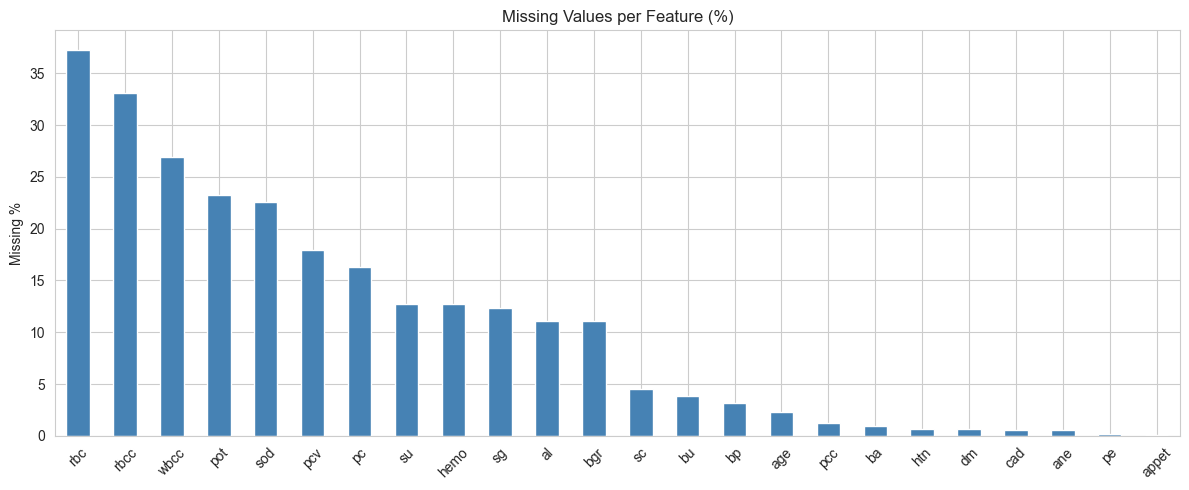

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)

plt.figure(figsize=(12, 5))
missing_df['Missing %'].plot(kind='bar', color='steelblue')
plt.title('Missing Values per Feature (%)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../report/missing_values.png', dpi=150)
plt.show()

=== Class Distribution ===
class
ckd       1566
notckd     934
Name: count, dtype: int64

Percentage:
class
ckd       62.64
notckd    37.36
Name: proportion, dtype: float64


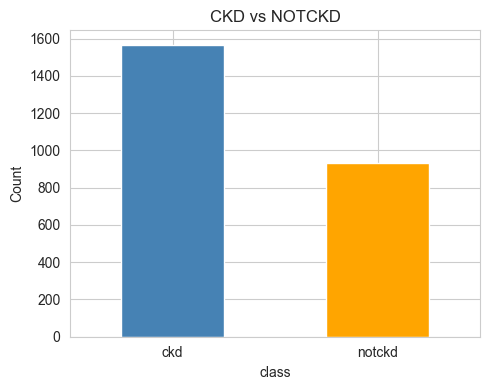

In [10]:
print("=== Class Distribution ===")
print(df['class'].value_counts())
print("\nPercentage:")
print(df['class'].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(5, 4))
df['class'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.title('CKD vs NOTCKD')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/class_distribution.png', dpi=150)
plt.show()

Numeric columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']


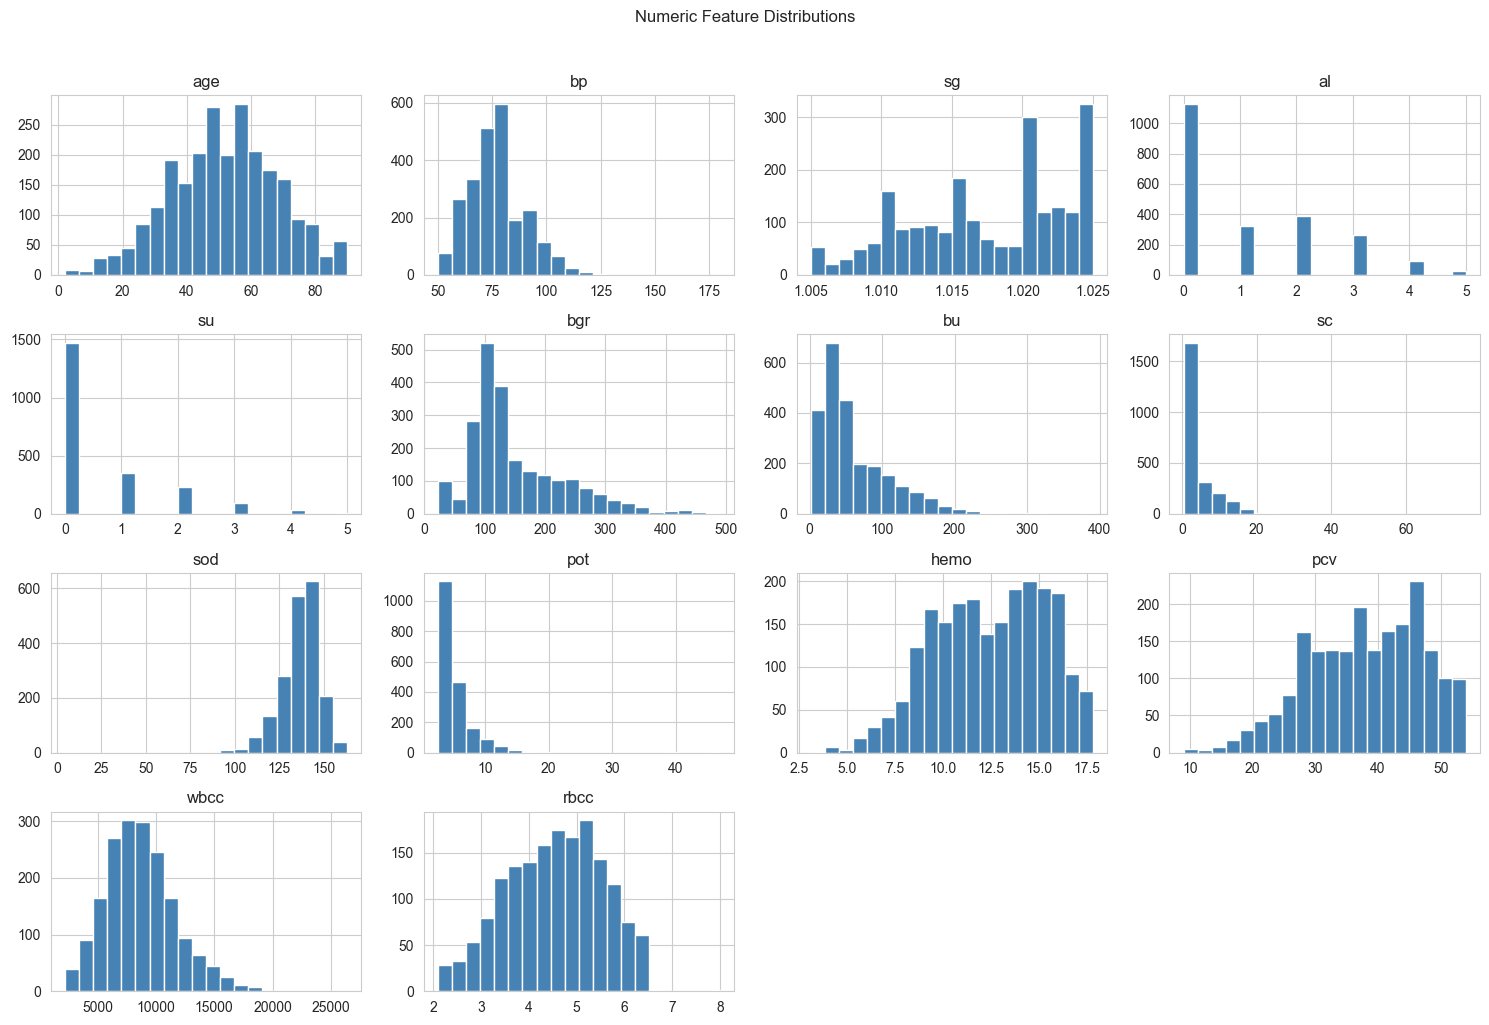

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", numeric_cols)

df[numeric_cols].hist(figsize=(15, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig('../report/numeric_distributions.png', dpi=150)
plt.show()

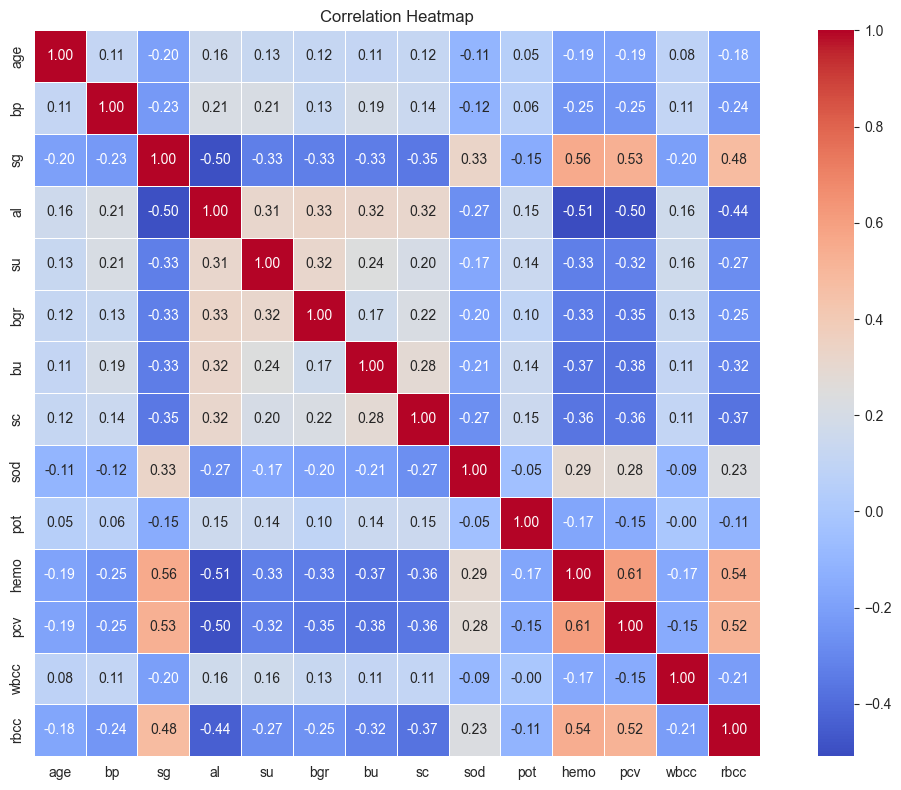

In [12]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', dpi=150)
plt.show()

C:\Users\WINDOW 10 PRO\AppData\Local\Temp\ipykernel_13036\3882739084.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


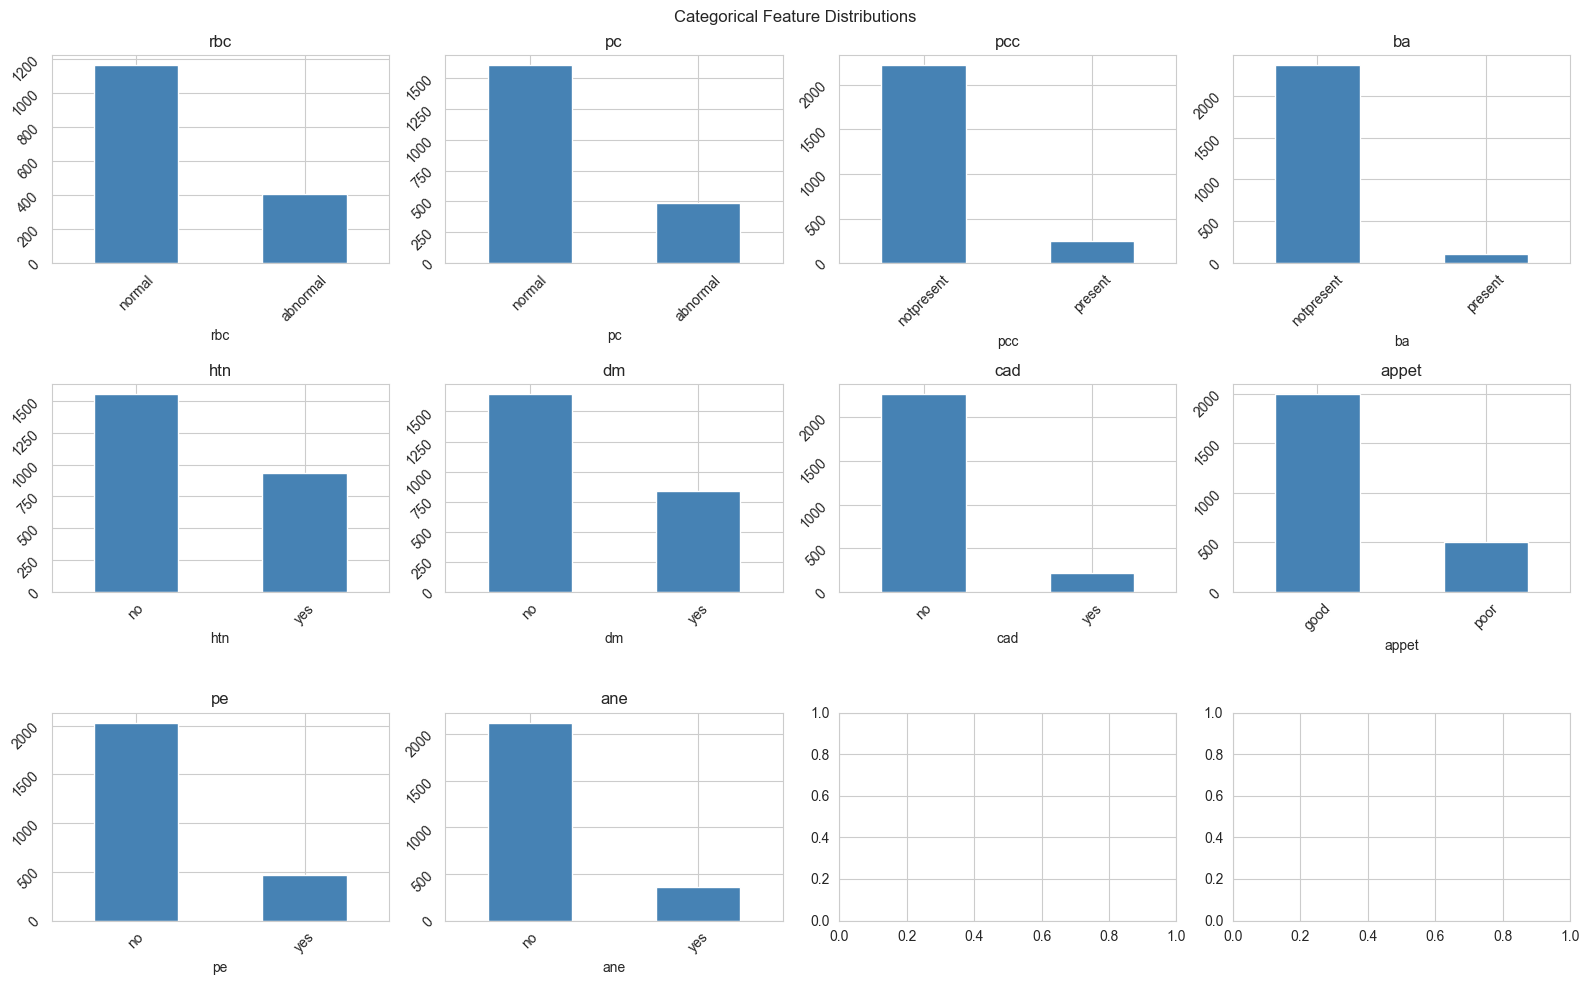

In [14]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'class']
print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(rotation=45)

plt.suptitle('Categorical Feature Distributions')
plt.tight_layout()
plt.savefig('../report/categorical_features.png', dpi=150)
plt.show()

## Key EDA Findings

- **Dataset:** 399 rows, 25 columns (24 features + 1 target)
- **Class Imbalance:** ~62.5% CKD, ~37.5% NOTCKD
- **Missing Values:** Multiple columns have missing data (max ~38% in rbcc)
- **Numeric Features:** 14 numeric, 10 categorical
- **Key Correlations:** hemo, pcv, rbcc strongly correlated with each other
- **Preprocessing Needed:** Imputation, encoding, scaling, class balancing